In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [40]:
df=pd.read_csv('/content/Netflix Dataset 1 (2).csv')

Content Trends Analysis for
Strategic Recommendations

In [41]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [43]:
df.isnull().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


In [44]:
# Correcting column names and dropping rows with missing values in relevant columns
df = df.dropna(subset=['Release_Date', 'Type', 'Country'])

# Fill missing values in 'Director' and 'Cast' columns with 'Unknown'
df['Director'].fillna('Unknown', inplace=True)
df['Cast'].fillna('Unknown', inplace=True)

# Fill missing values in 'Rating' with the mode
df['Rating'].fillna(df['Rating'].mode()[0], inplace=True)

# Display the number of missing values after filling
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64


Objective 1: distribution of Movies vs. TV Shows over the years.

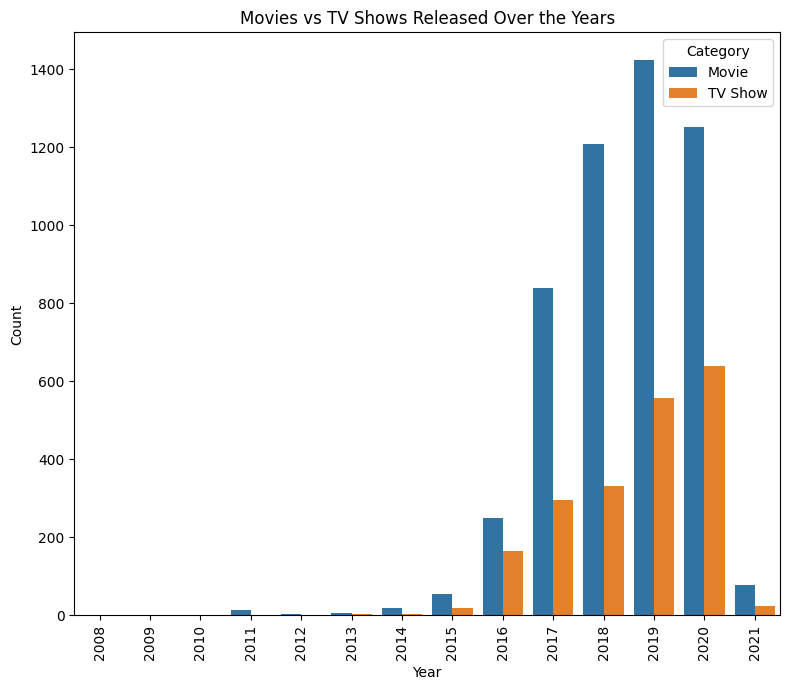

In [45]:
# Convert 'Release_Date' to datetime objects and extract the year
df['Release_Year'] = pd.to_datetime(df['Release_Date'], errors='coerce').dt.year

# Drop rows where Release_Year is NaN (due to conversion errors)
df.dropna(subset=['Release_Year'], inplace=True)

# Convert Release_Year to integer
df['Release_Year'] = df['Release_Year'].astype(int)

# Count movies vs TV shows per year
type_counts = df.groupby(['Release_Year', 'Category']).size().reset_index(name='count')

plt.figure(figsize=(8, 7))
sns.barplot(data=type_counts, x='Release_Year', y='count', hue='Category')

plt.title('Movies vs TV Shows Released Over the Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#This bar graph helps us analyse that Movie production > TV show production
#However there has been an increase in the production of Tv shows compred to earlier years
#A sudden drop in the production for both was observed in 2021

Objective 2- Identify the most common genres and how their popularity has changed.

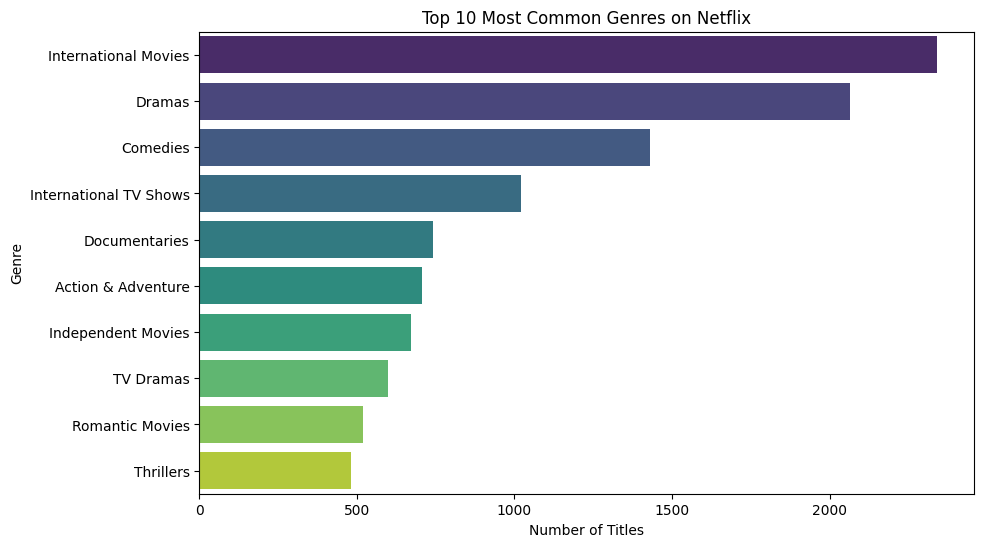

In [46]:
# Split genres and explode
genres = df['Type'].dropna().str.split(',').explode().str.strip()

# Count most common genres
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')

plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

#It is esy to observe that interntional movies si the most common genre along with thrillers being the least popular
#This shows the diversity of the viewers

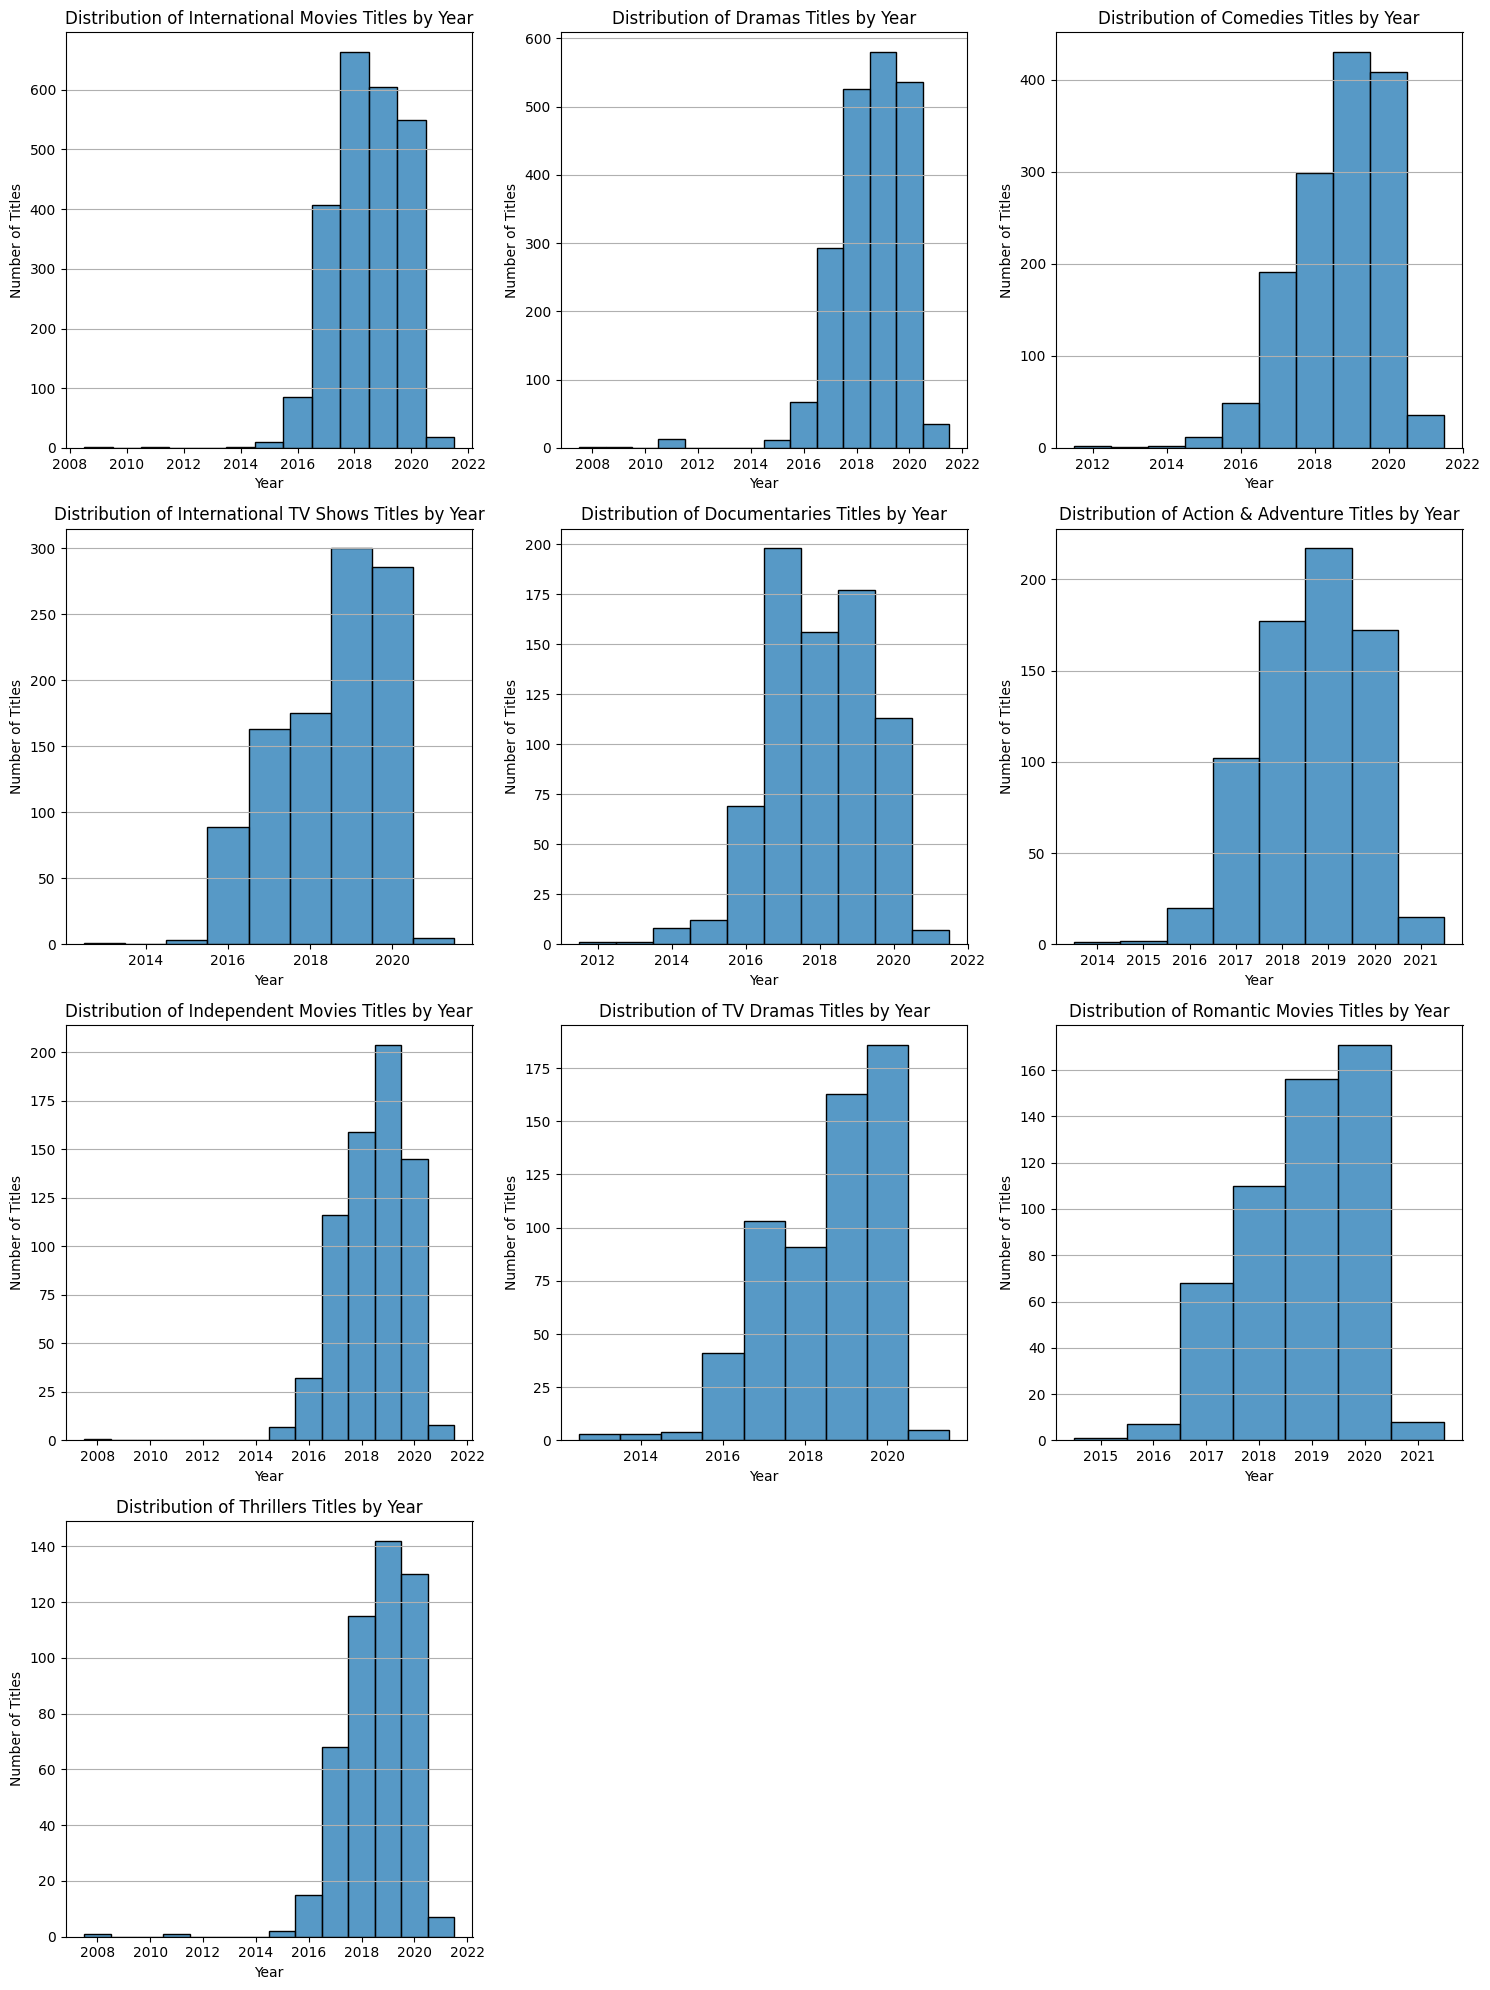

In [47]:
# Plotting histograms for the top 10 genres
n_genres = len(top_10_genres)
n_cols = 3  # Number of columns for subplots
n_rows = (n_genres + n_cols - 1) // n_cols  # Calculate number of rows

plt.figure(figsize=(15, n_rows * 5))

for i, genre in enumerate(top_10_genres):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=genre_trends_top[genre_trends_top['Type'] == genre], x='Release_Year', weights='count', discrete=True, kde=False)
    plt.title(f'Distribution of {genre} Titles by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Titles')
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

#Continuous data:
#Histograms are used for continuous data, where the variable can take any value within a range
#They help to see where the
#data is concentrated and identify the mode(s) (the most frequent value or range).
#Identification of top-performing genres and categories.

Objective 3- Compare country-wise contributions to Netflix’s catalog

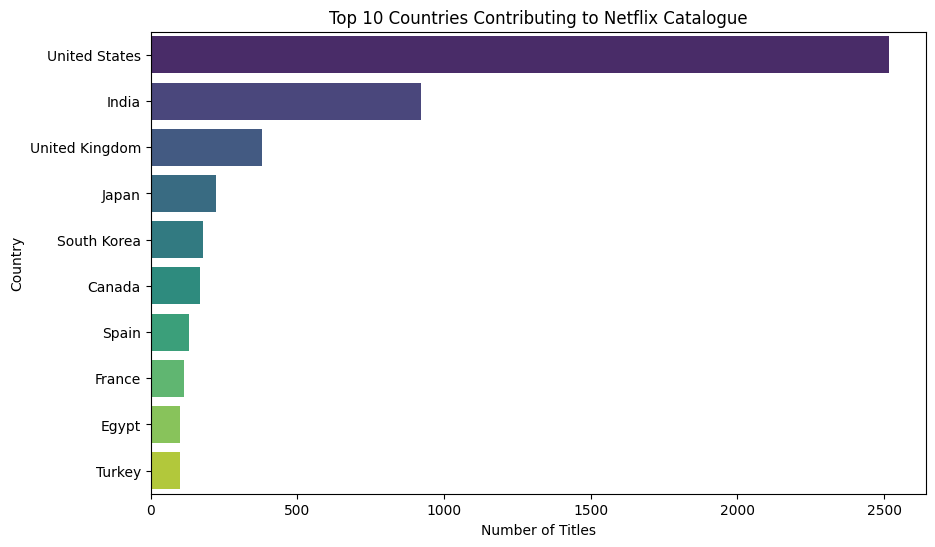

In [48]:
# Count the number of titles per country
country_counts = df['Country'].value_counts().head(10)

# Plot the top 10 countries
plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title('Top 10 Countries Contributing to Netflix Catalogue')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()



Understanding how Netflix’s content strategy has evolved.

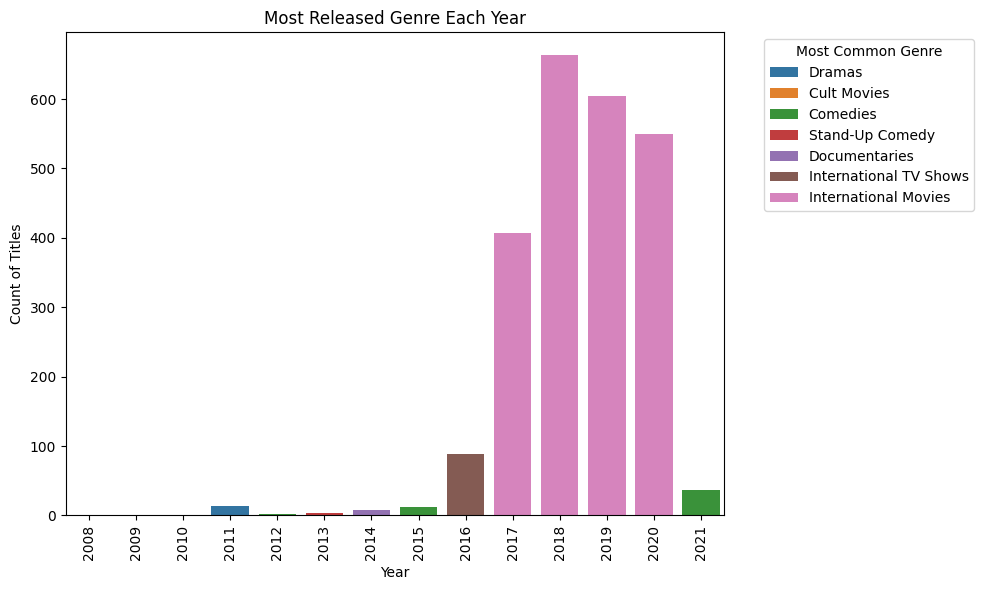

In [49]:

genres_df = df.assign(Type=df['Type'].str.split(',')).explode('Type')
genres_df['Type'] = genres_df['Type'].str.strip()
genre_trends = genres_df.groupby(['Release_Year', 'Type']).size().reset_index(name='count')


# Find the genre with the maximum count for each year
most_common_genre_per_year = genre_trends.loc[genre_trends.groupby('Release_Year')['count'].idxmax()]

# Plotting the most common genre released each year
plt.figure(figsize=(10, 6))
sns.barplot(data=most_common_genre_per_year, x='Release_Year', y='count', hue='Type', dodge=False)

plt.title('Most Released Genre Each Year')
plt.xlabel('Year')
plt.ylabel('Count of Titles')
plt.xticks(rotation=90)
plt.legend(title='Most Common Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Strategic recommendations on which content types Netflix should focus on in the
future.

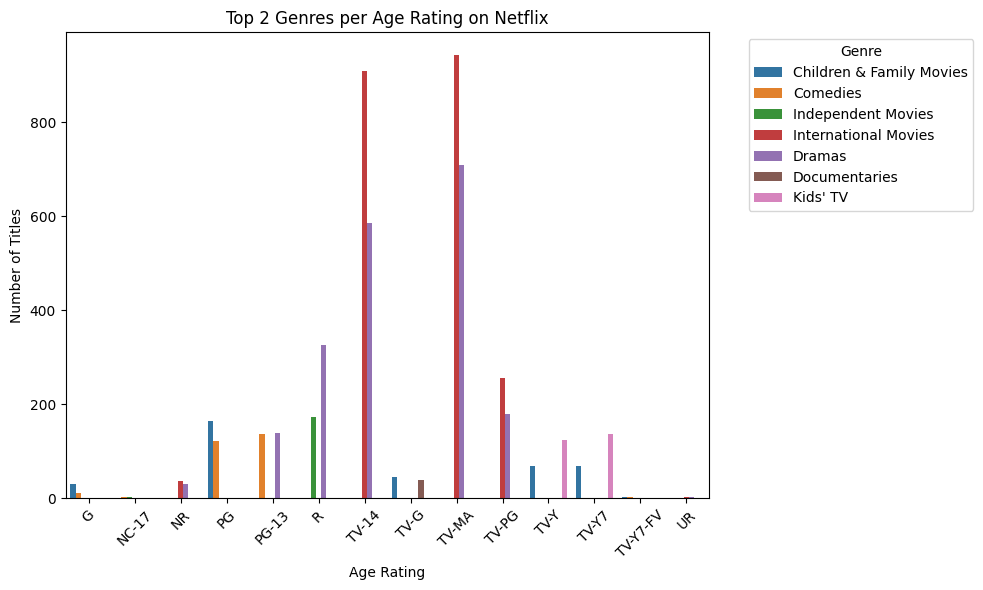

In [51]:

genres_df = df.assign(Type=df['Type'].str.split(',')).explode('Type')
genres_df['Type'] = genres_df['Type'].str.strip()

# Group by Rating and Type and count occurrences
rating_genre_counts = genres_df.groupby(['Rating', 'Type']).size().reset_index(name='count')

# Find the top 2 genres for each rating
top_genres_per_rating = rating_genre_counts.groupby('Rating').apply(lambda x: x.nlargest(2, 'count')).reset_index(drop=True)

# Plotting the top 2 genres per rating
plt.figure(figsize=(10, 6))
sns.barplot(data=top_genres_per_rating, x='Rating', y='count', hue='Type', palette='tab10', width=0.8) # Increased width

plt.title('Top 2 Genres per Age Rating on Netflix')
plt.xlabel('Age Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Recommendations should be done according to age group
